# BayesianNetwork-SCM Model Comparison

This notebook analyzes the current Dynamic BN-SCM results against three graph spreading baselines: NDM, ESM, and SIR. The comparison uses the same ADNI baseline-to-follow-up pair table and the same subject-level train/validation/test split as the BN-SCM run.

**Important scope:** BN-SCM is fit on the selected annualized regional tau rates. NDM, ESM, and SIR are fit on the full 68-region ENIGMA/aparc tau graph, then evaluated only on the selected BN-SCM tau regions. This gives the graph models their full network context while keeping the held-out evaluation target identical.

In [6]:
from pathlib import Path
import csv
import json
import sys

from IPython.display import Image, Markdown, SVG, display

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / 'BayesianNetwork-SCM').exists():
    PROJECT_ROOT = NOTEBOOK_DIR
elif NOTEBOOK_DIR.name == 'BayesianNetwork-SCM':
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = Path('..').resolve()
ANALYSIS_DIR = PROJECT_ROOT / 'BayesianNetwork-SCM'
OUTPUT_DIR = ANALYSIS_DIR / 'outputs'
REPORT_PATH = OUTPUT_DIR / 'model_comparison_report.json'

# Set this to True to refit BN-SCM, NDM, ESM, and SIR and regenerate all tables/figures.
RUN_FULL_ANALYSIS = False

if RUN_FULL_ANALYSIS:
    sys.path.insert(0, str(ANALYSIS_DIR))
    from analyze_model_comparison import run_analysis
    report = run_analysis(project_root=PROJECT_ROOT, output_dir=OUTPUT_DIR)
else:
    report = json.loads(REPORT_PATH.read_text())

report['split'], report['comparison_scope']

({'test_pairs': 156,
  'test_subjects': 108,
  'train_pairs': 473,
  'train_subjects': 325,
  'validation_pairs': 167,
  'validation_subjects': 108},
 {'bn_scm_fit': 'selected regional tau annualized rates',
  'evaluation_targets': ['L_entorhinal',
   'R_entorhinal',
   'L_fusiform',
   'R_fusiform',
   'L_inferiortemporal',
   'R_inferiortemporal',
   'L_middletemporal',
   'R_middletemporal',
   'L_inferiorparietal',
   'R_inferiorparietal'],
  'graph_models_fit': 'full 68-region ENIGMA/aparc tau states',
  'metric_unit': 'follow-up tau SUVR and annualized tau SUVR/year'})

## Main Findings

1. **BN-SCM is strongest on annualized tau-rate forecasting**, which is the target it was designed to learn. In the current run, test median rate MAE is lower for BN-SCM than NDM, ESM, SIR, and S0 persistence.
2. **Absolute follow-up SUVR is dominated by baseline tau anatomy.** S0 persistence, ESM, SIR, and BN-SCM are very close on follow-up MAE and subject-level spatial Spearman. This is expected when most of the follow-up rank structure is already present at baseline.
3. **Delta-rank prediction is the more relevant spreading test.** BN-SCM has the best held-out delta Spearman among these four mechanistic baselines, but the value is still modest, so this should be interpreted as early evidence rather than a solved causal mechanism.
4. **NDM is a weak comparator in this selected-region test.** It fits rho at the upper bound and performs poorly on absolute spatial rank, suggesting that raw linear diffusion is not well calibrated for these tau SUVR dynamics under the current preprocessing.
5. **The causal component remains prototype-level.** Current BN-SCM uses constrained varying-coefficient ridge effects, not full posterior graph MCMC, so edge curves are descriptive and should not be read as posterior causal inclusion probabilities.

In [7]:
def read_csv_rows(path):
    with Path(path).open(newline='') as handle:
        return list(csv.DictReader(handle))

def markdown_table(rows, columns, title=None):
    lines = []
    if title:
        lines.extend([f'### {title}', ''])
    lines.append('| ' + ' | '.join(columns) + ' |')
    lines.append('| ' + ' | '.join(['---'] * len(columns)) + ' |')
    for row in rows:
        lines.append('| ' + ' | '.join(str(row.get(col, '')) for col in columns) + ' |')
    return Markdown('\n'.join(lines))

summary_rows = read_csv_rows(OUTPUT_DIR / 'model_comparison_summary.csv')
test_summary = []
for model in ['BayesianNetwork-SCM', 'NDM', 'ESM', 'SIR', 'S0 persistence']:
    row = {'model': model}
    for metric in ['mae_suvr', 'rate_mae', 'subject_spearman', 'delta_spearman']:
        match = [r for r in summary_rows if r['model'] == model and r['split'] == 'test' and r['metric'] == metric]
        row[metric] = 'NA' if not match else f"{float(match[0]['median']):.4f}"
    test_summary.append(row)

display(markdown_table(test_summary, ['model', 'mae_suvr', 'rate_mae', 'subject_spearman', 'delta_spearman'], 'Held-Out Test Medians'))

### Held-Out Test Medians

| model | mae_suvr | rate_mae | subject_spearman | delta_spearman |
| --- | --- | --- | --- | --- |
| BayesianNetwork-SCM | 0.0482 | 0.0144 | 0.8061 | 0.2215 |
| NDM | 0.1056 | 0.0399 | -0.0516 | 0.0424 |
| ESM | 0.0484 | 0.0166 | 0.8194 | -0.1092 |
| SIR | 0.0478 | 0.0163 | 0.8255 | -0.0972 |
| S0 persistence | 0.0482 | 0.0176 | 0.8285 | NA |

## 1. Overall Held-Out Performance

The first figure compares the median held-out pair-level metrics. The key distinction is between **follow-up SUVR error**, which rewards staying close to baseline, and **rate/delta metrics**, which test whether the model predicts the spatial direction of tau change.

![Held-out model comparison](outputs/figures/model_comparison_test_metrics.svg)

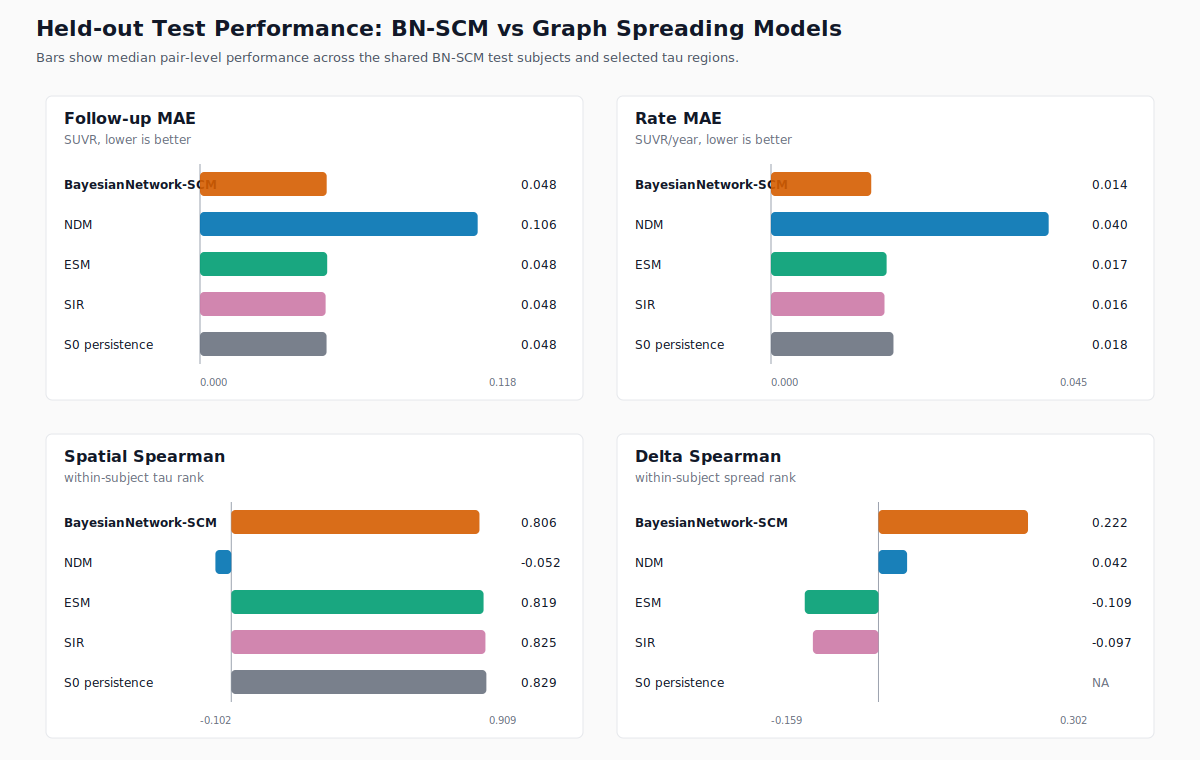

In [8]:
display(SVG(filename=str(OUTPUT_DIR / 'figures/model_comparison_test_metrics.svg')))

## 2. Regional Rate Forecasting

This heatmap shows where each model succeeds or fails regionally. The evaluation is limited to the tau regions used by BN-SCM, so this is not a whole-cortex graph-model score.

![Regional rate MAE heatmap](outputs/figures/regional_rate_mae_heatmap.svg)

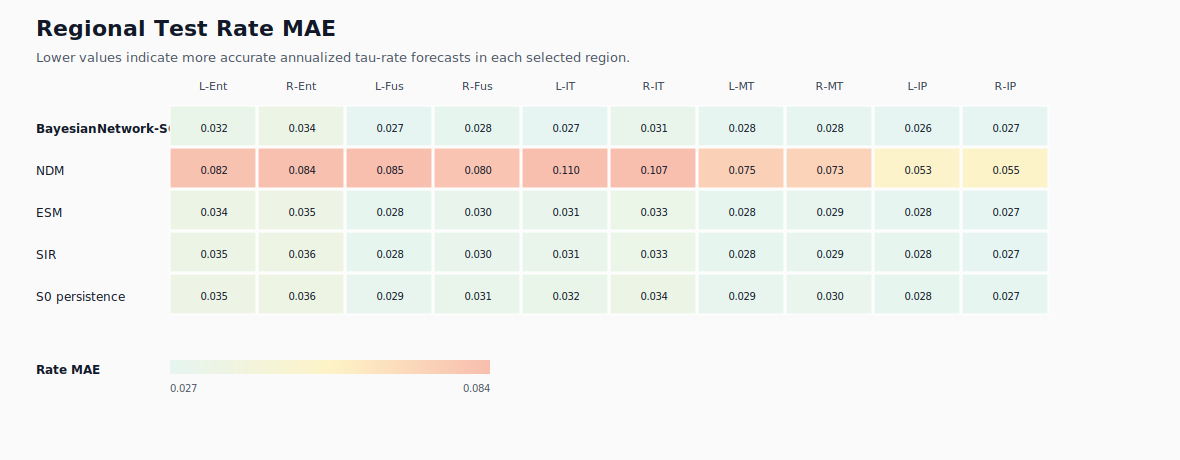

In [9]:
display(SVG(filename=str(OUTPUT_DIR / 'figures/regional_rate_mae_heatmap.svg')))

## 3. Predicted vs Observed Tau Rate

Each point is one held-out subject-region pair. The identity line is perfect annualized tau-rate prediction. This view makes the persistence problem clear: a model can be close in follow-up SUVR while still failing to predict the sign or rank of future change.

![Predicted vs observed tau rate](outputs/figures/predicted_vs_observed_tau_rate.svg)

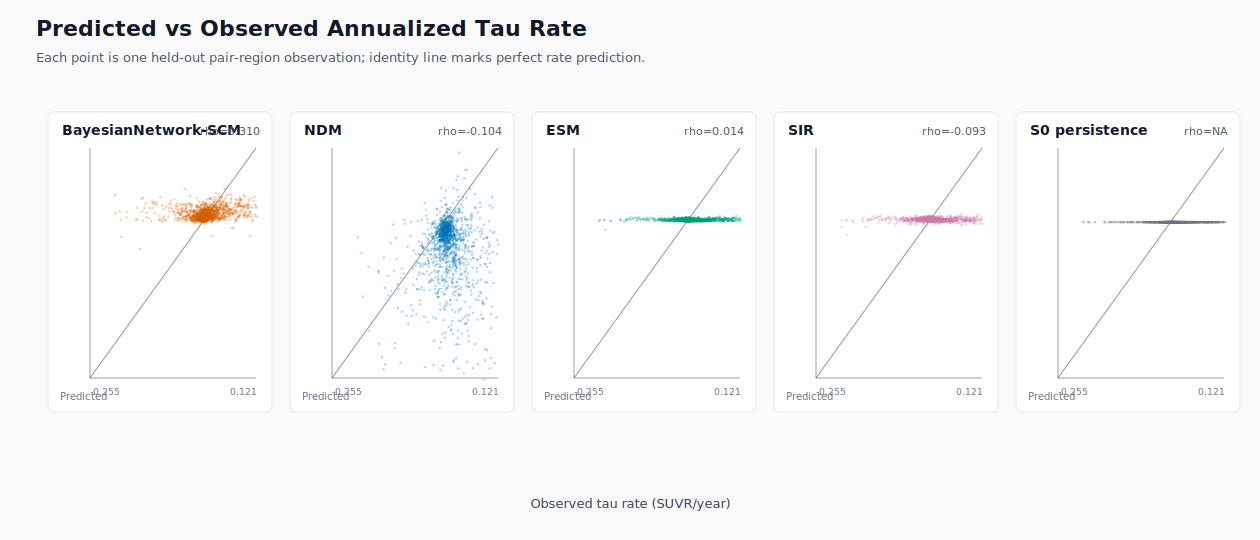

In [10]:
display(SVG(filename=str(OUTPUT_DIR / 'figures/predicted_vs_observed_tau_rate.svg')))

## 4. BN-SCM Dynamic Edge Effects

The BN-SCM edge curves show how selected parent effects vary across disease pseudotime. These are useful for hypothesis generation, but they are still ridge-estimated varying effects. They are **not** posterior inclusion probabilities and should not yet be treated as final causal evidence.

![BN-SCM edge effects](outputs/figures/bn_scm_top_edge_effects.svg)

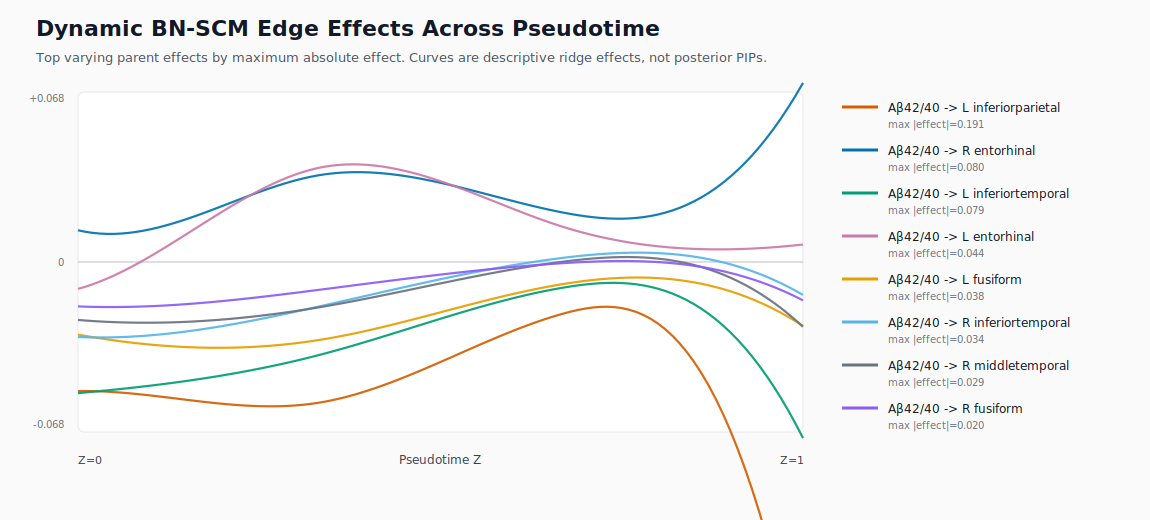

In [11]:
display(SVG(filename=str(OUTPUT_DIR / 'figures/bn_scm_top_edge_effects.svg')))

## 5. Explainable Pseudotime Z

Z is fitted from train rows only using non-tau, non-p-tau217 features in the current `tau_free` mode. The diagnostic ordering check is a sanity test: if Z is biologically meaningful, CN should generally lie earlier than MCI/AD while still allowing overlap.

![Pseudotime by diagnosis](outputs/figures/pseudotime_diagnosis.svg)

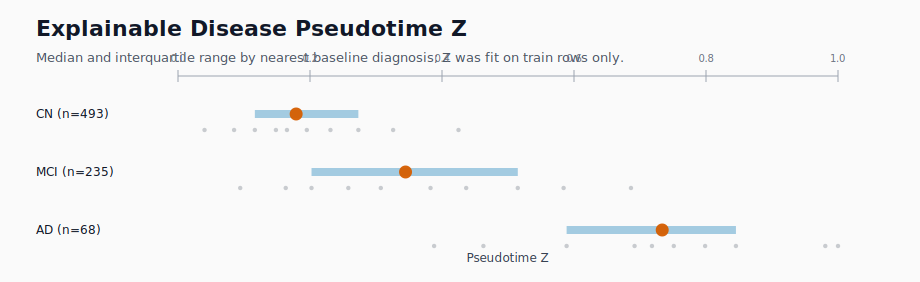

In [12]:
display(SVG(filename=str(OUTPUT_DIR / 'figures/pseudotime_diagnosis.svg')))

## Fit Diagnostics

The cell below summarizes the model equations and fitted graph parameters. The current NDM fit should be read cautiously because rho is at the upper optimization bound.

In [13]:
fit_rows = []
for model, values in report['fit_reports'].items():
    fit_rows.append({
        'model': model,
        'equation': values.get('equation', ''),
        'fit_scope': values.get('fit_scope', ''),
        'rho': '' if 'rho' not in values else f"{values['rho']:.4f}",
        'beta': '' if 'beta' not in values else f"{values['beta']:.4f}",
        'gamma': '' if 'gamma' not in values else f"{values['gamma']:.4f}",
    })

display(markdown_table(fit_rows, ['model', 'equation', 'fit_scope', 'rho', 'beta', 'gamma'], 'Model Fit Reports'))

### Model Fit Reports

| model | equation | fit_scope | rho | beta | gamma |
| --- | --- | --- | --- | --- | --- |
| BayesianNetwork-SCM | dX_j/dt = a_j(Z) + self_j(Z) X_j(0) + sum_l b_jl(Z) X_l(0) | selected tau rates only |  |  |  |
| ESM | dS/dt = beta (1 - S) W S | full 68-region tau graph, min-max state scaled |  | 0.0128 |  |
| NDM | dS/dt = -rho L S | full 68-region tau graph | 10.0000 |  |  |
| S0 persistence | S(t) = S(0) | no learned parameters |  |  |  |
| SIR | dI/dt = beta S (W I) - gamma I; observed tau = I | full 68-region tau graph, min-max state scaled |  | 0.0209 | 0.0063 |

## 6. Regional Tau Burden: S0 to S1 across models

The figures below give a region-level view of empirical tau change against each model's prediction on the same 156 held-out pairs (mean follow-up window 3.4 years).

- The first figure plots the annualized SUVR rate per region (`(Y(t1) - Y(t0)) / dt`) for the observed signal in gray and each model's predicted rate in color. Bars below zero indicate predicted decreases.
- The second figure projects S0, observed S1, observed S1 - S0, and each model's predicted S1 - S0 onto a schematic DK aparc map. Only the 10 BN-SCM target regions are colored; un-modelled DK regions are shown in light grey.
- The new nilearn panels render the same comparison on fsaverage5 cortical surfaces using nilearn's Destrieux surface atlas. Because nilearn does not ship a DK/aparc surface atlas, the 10 DK/aparc target regions are mapped to nearest Destrieux parcels and the mapping is saved as `outputs/figures/region_tau_burden_nilearn_mapping.csv`.

**Reading the comparison.** BN-LTE-2 (the older same-time SCM from `BayesianNetwork-SCM-2`) collapses to large-magnitude negative regional rates - this is the same anti-correlation failure mode visible in its test-set Spearman. NDM, ESM, and SIR stay near the persistence baseline (rates close to zero) because their spreading dynamics on the HCP group-average connectome do not move much over a 3-4 year window on this cohort. BN-SCM is the only model whose per-region predicted rates track the sign and rough magnitude of the empirical change.

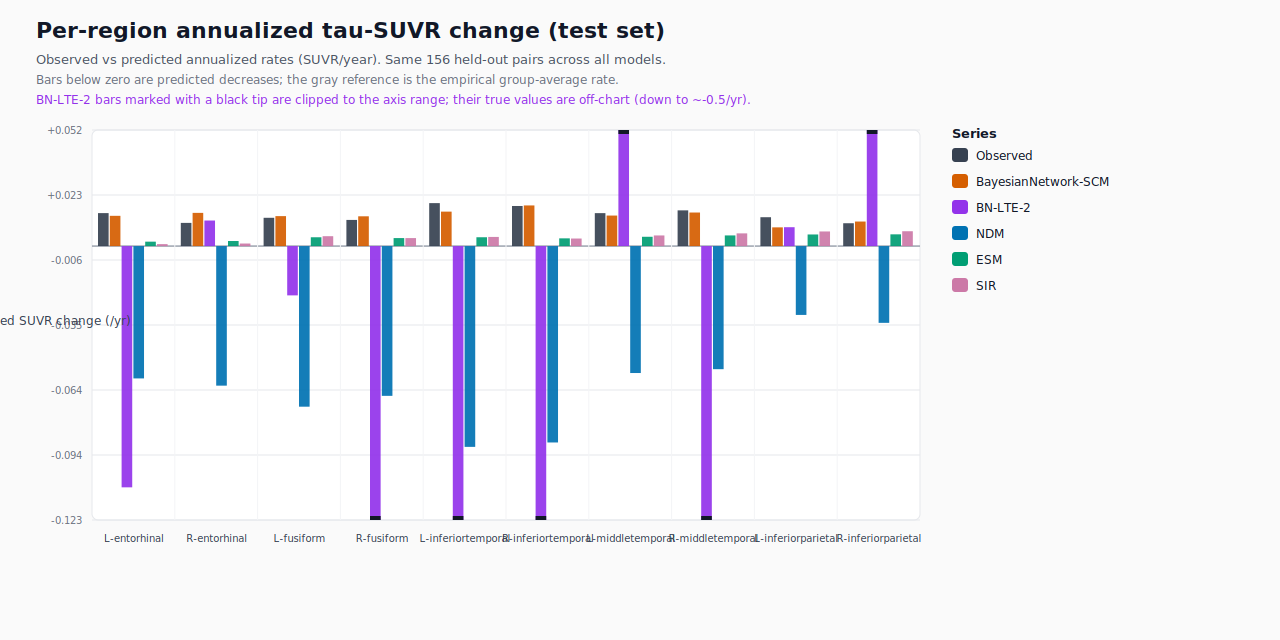

In [14]:
display(SVG(filename=str(OUTPUT_DIR / 'figures/region_burden_change_bars.svg')))

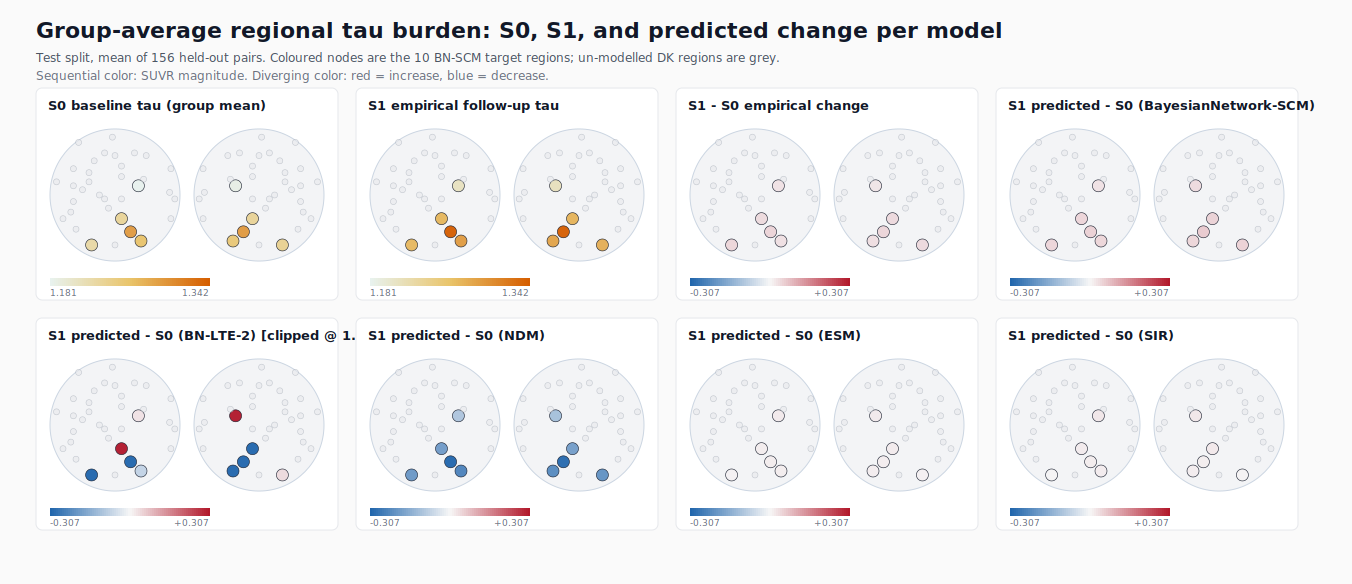

In [15]:
display(SVG(filename=str(OUTPUT_DIR / 'figures/region_burden_change_brain.svg')))

### Nilearn Surface View

The next two figures use nilearn `fsaverage5` surfaces with left/right lateral and ventral views. The absolute-burden panel compares baseline, empirical follow-up, BN-SCM / BN-LTE, BN-LTE-2, NDM, ESM, and SIR on the same empirical SUVR color scale. The error panel shows predicted follow-up minus empirical follow-up.

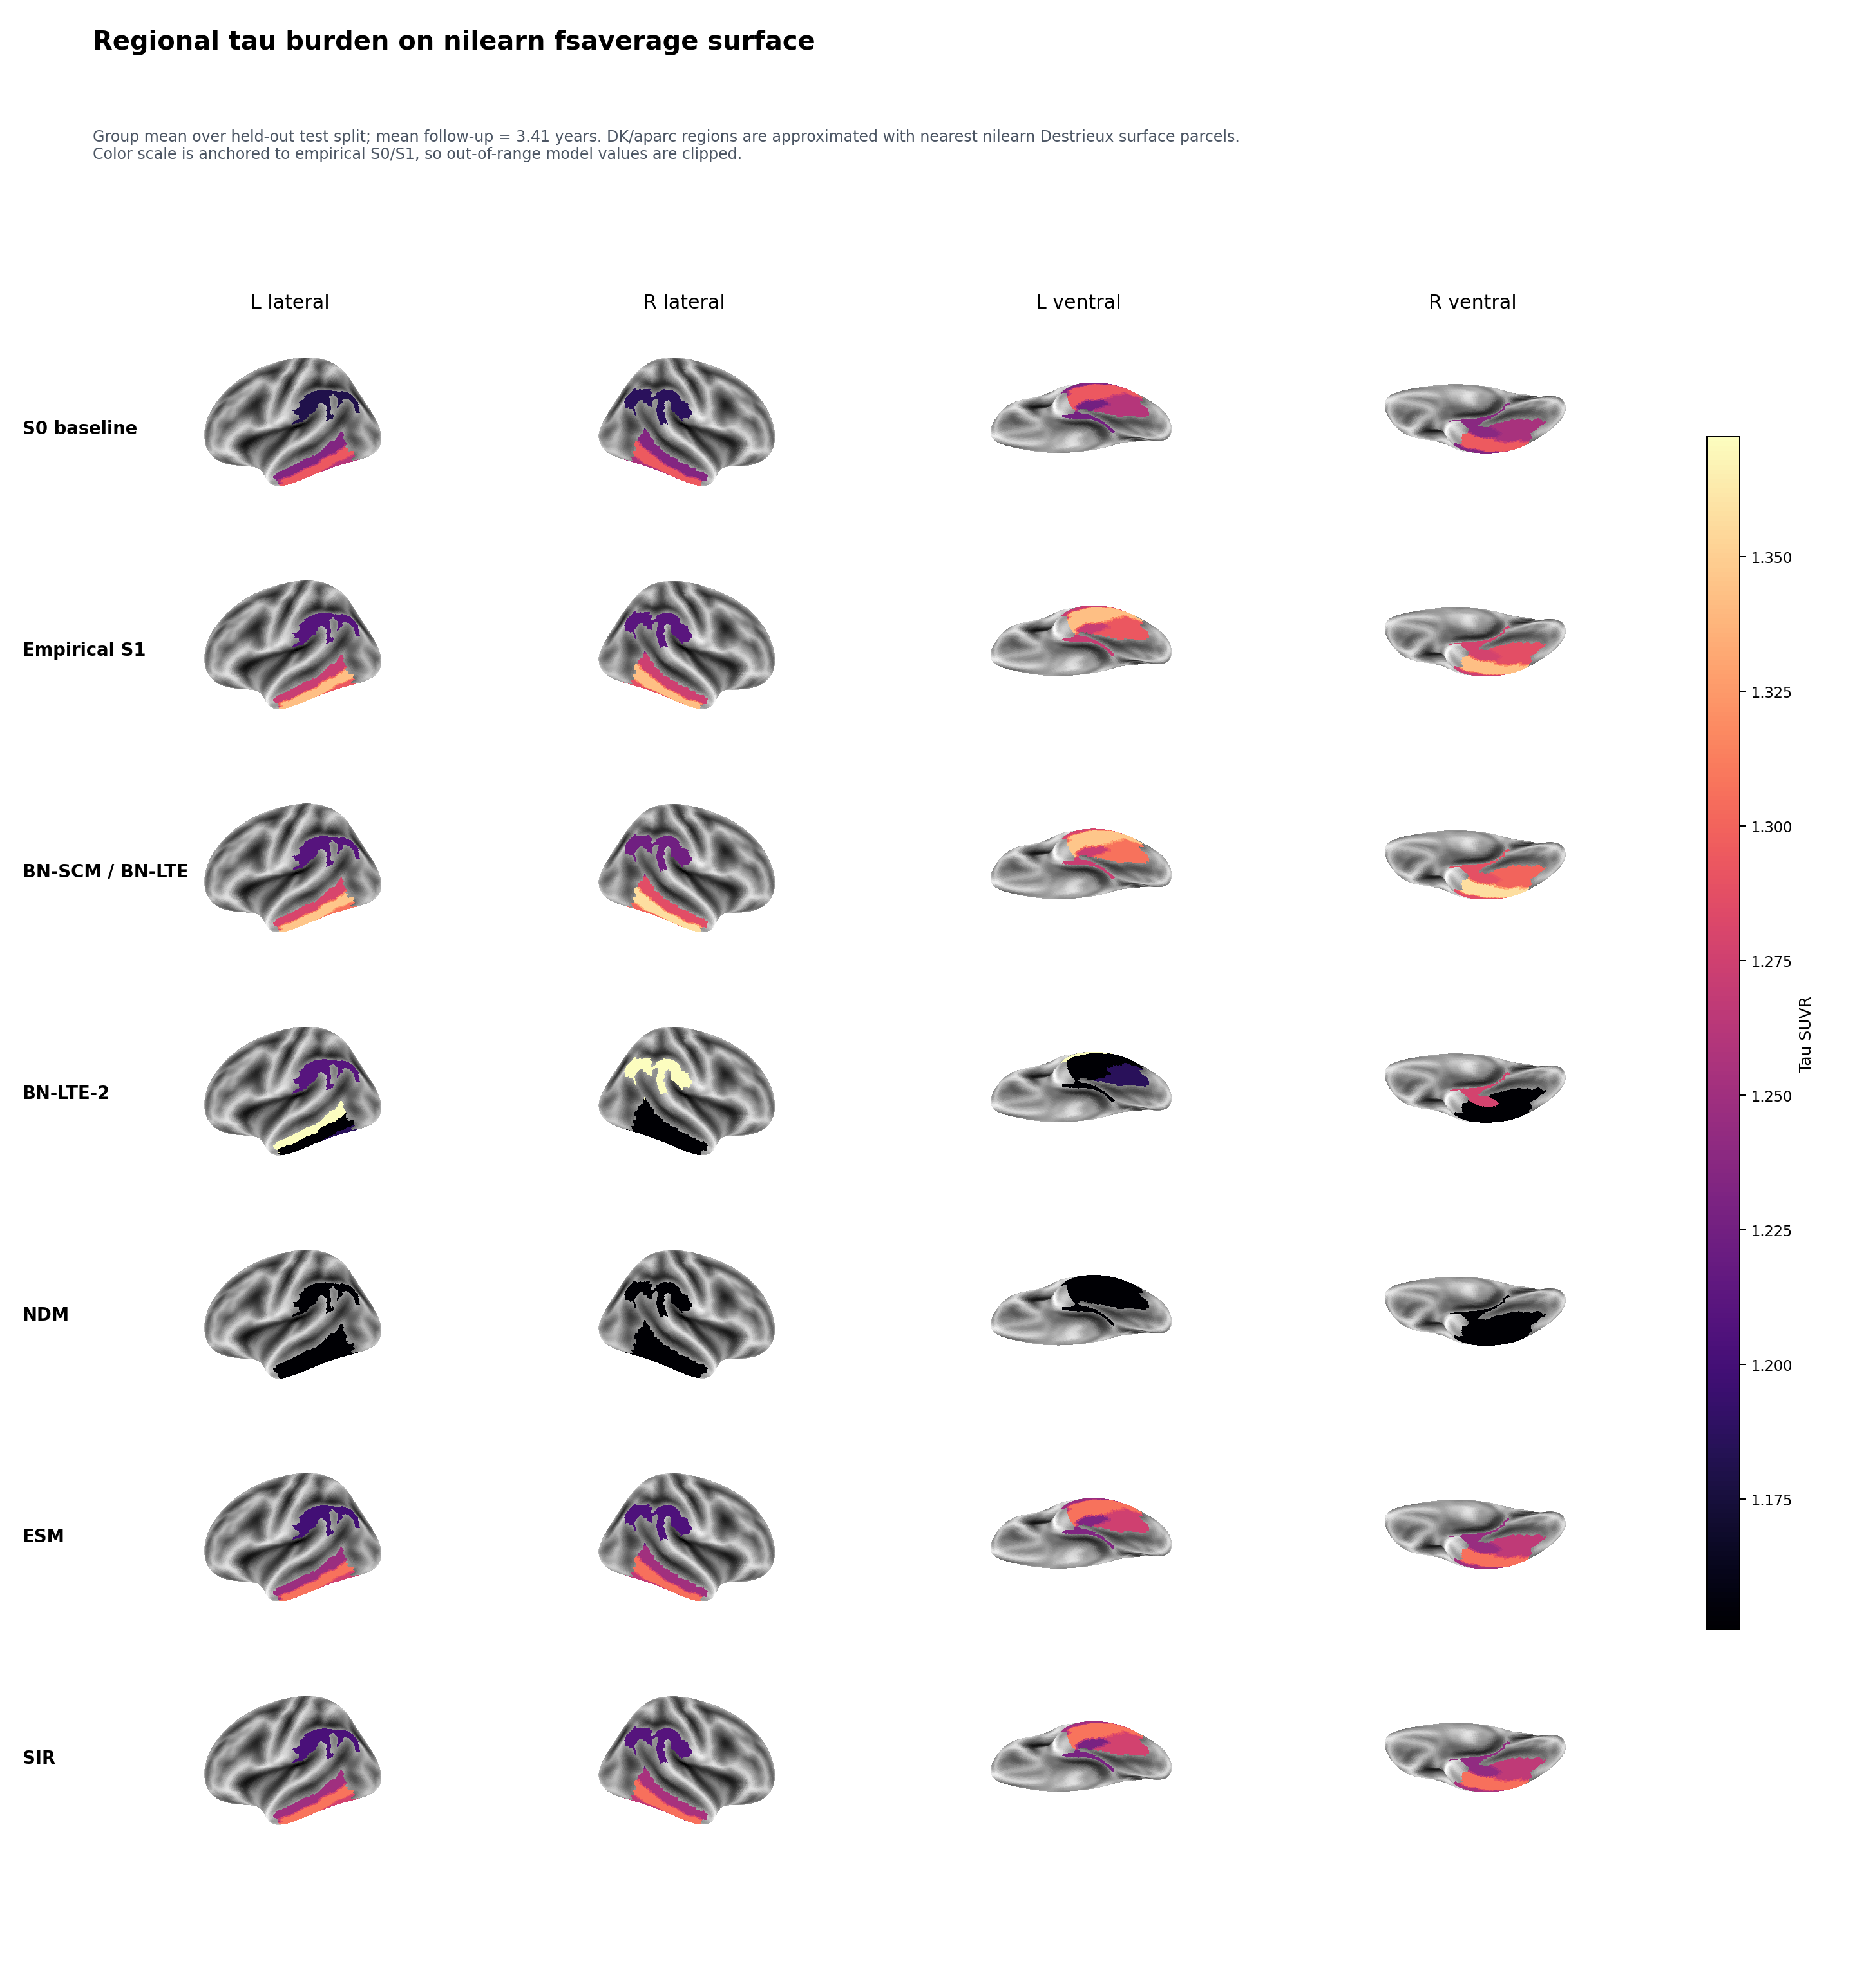

In [16]:
display(Image(filename=str(OUTPUT_DIR / 'figures/region_tau_burden_nilearn_surface.png')))

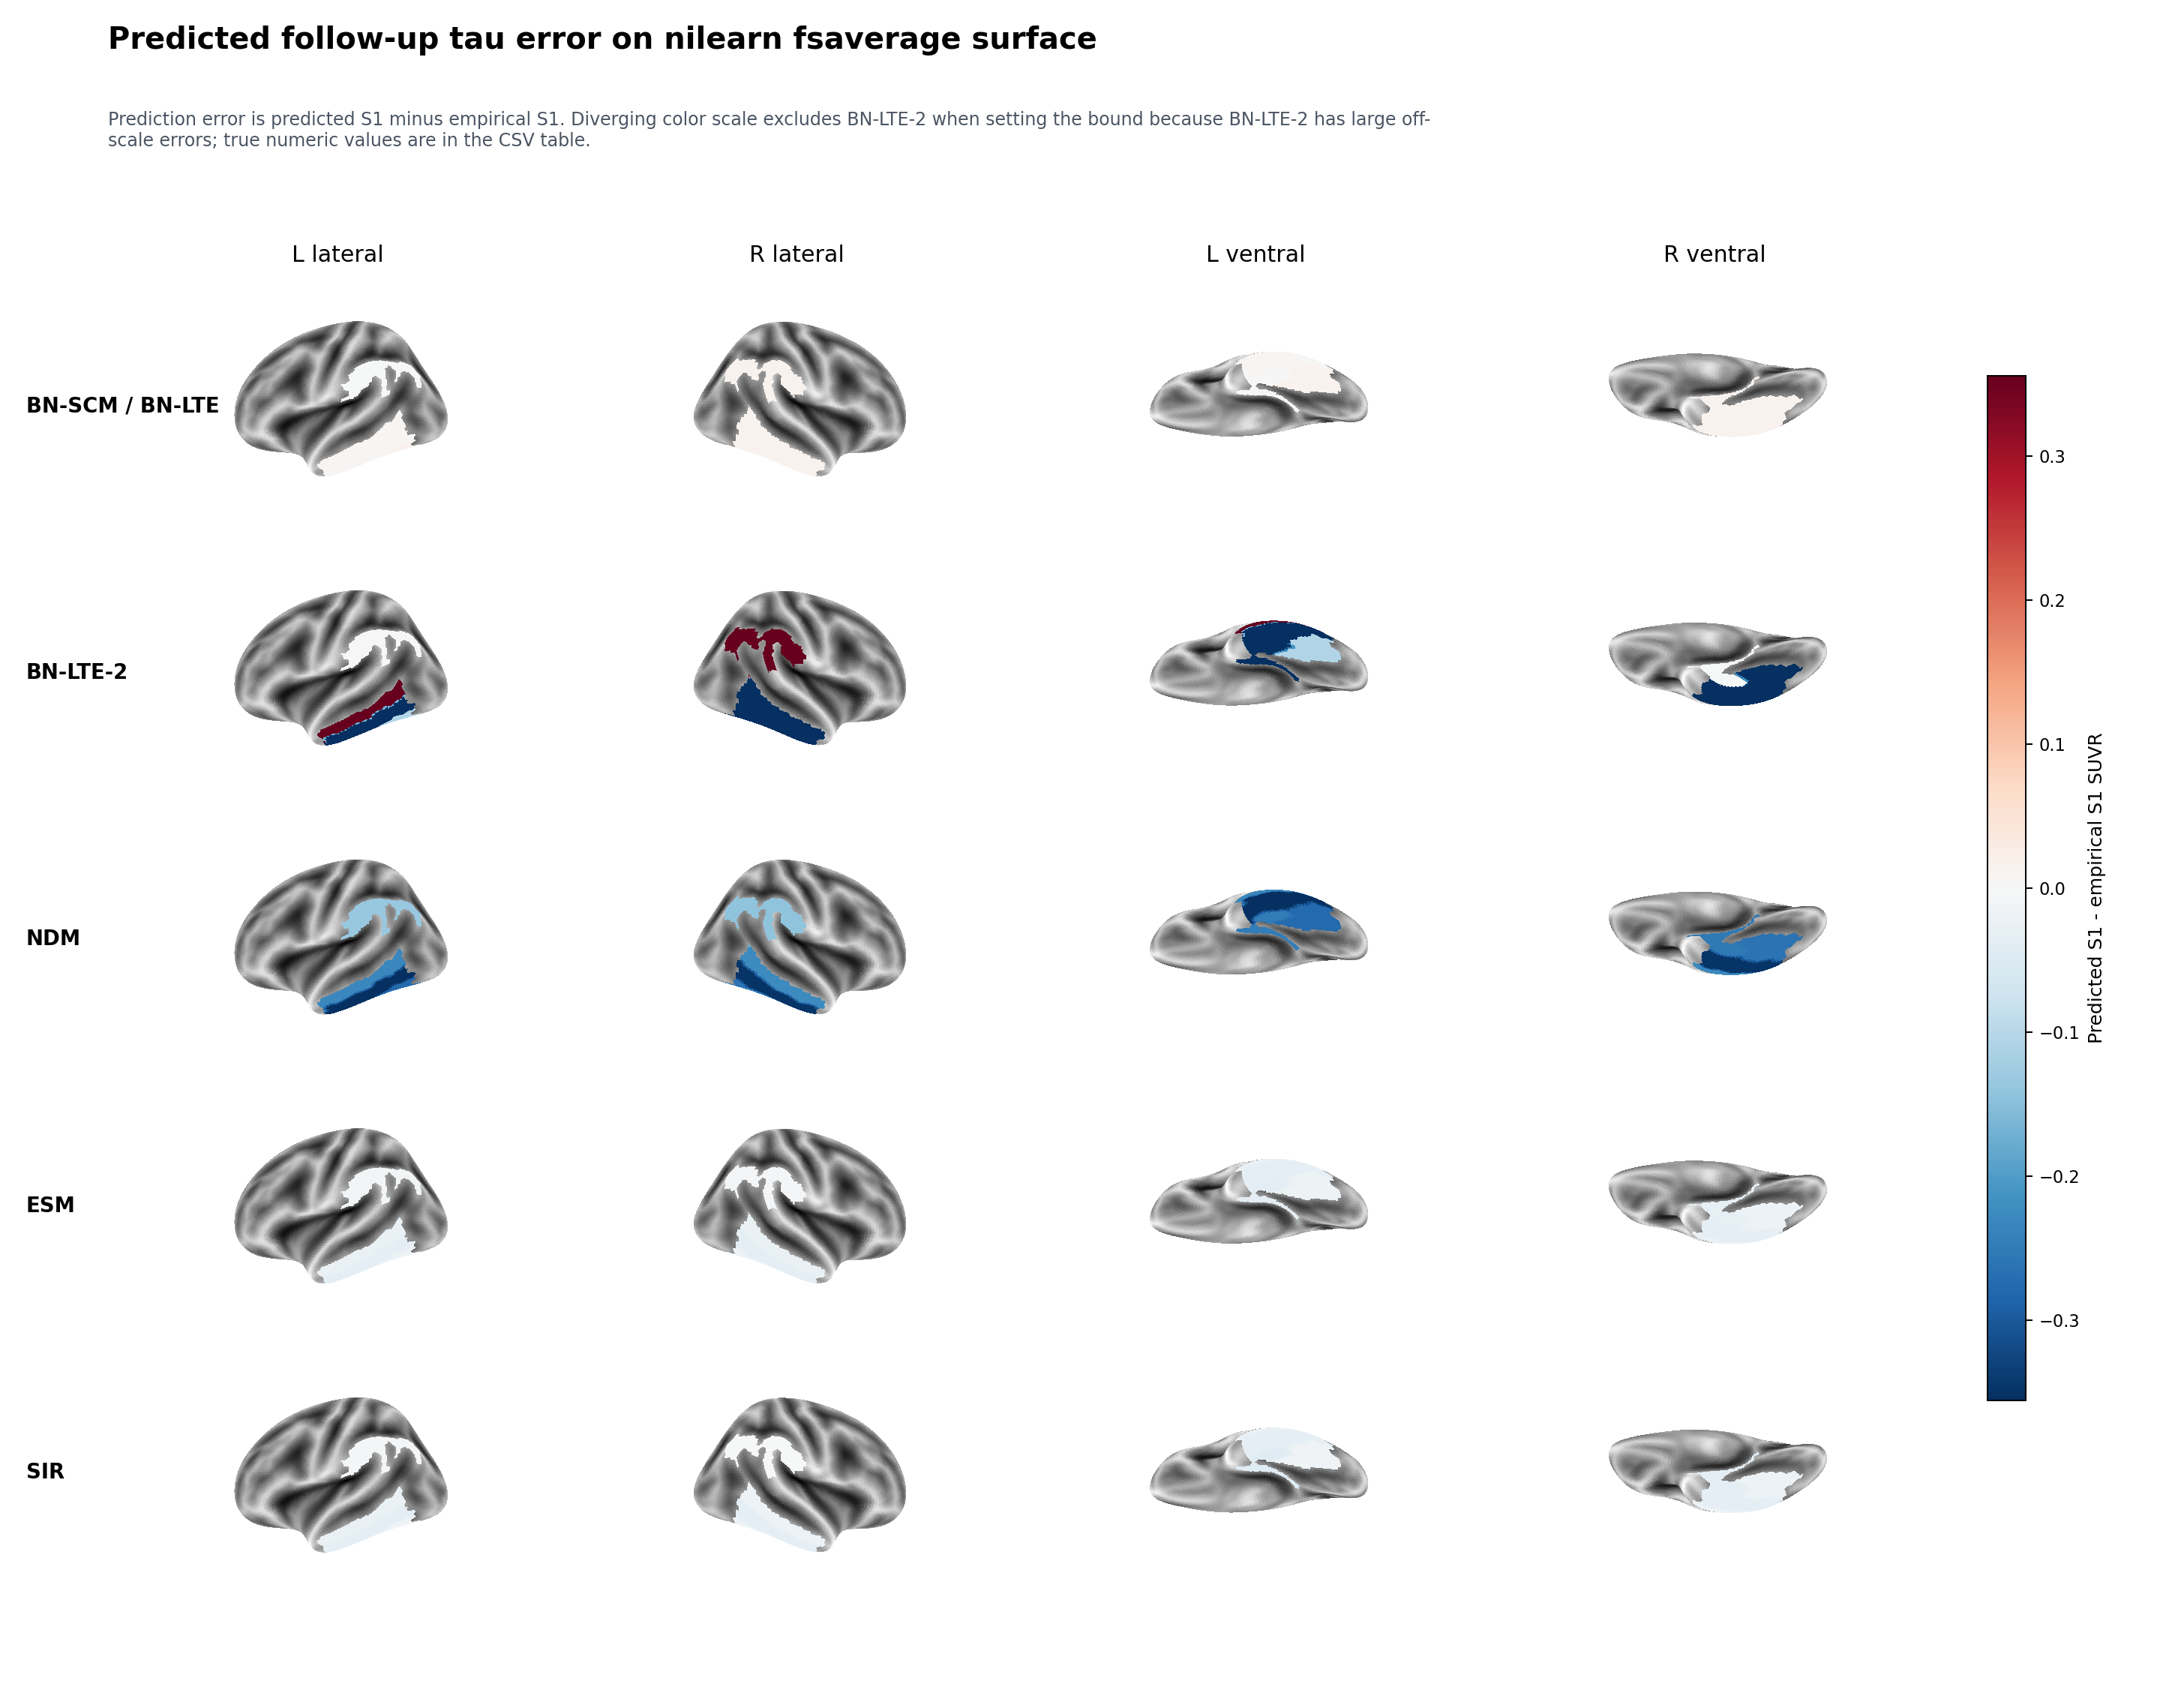

In [17]:
display(Image(filename=str(OUTPUT_DIR / 'figures/region_tau_burden_nilearn_error_surface.png')))

## Interpretation Limits

This notebook compares forecasting behavior. It does not prove causal identifiability. The current BN-SCM implementation is useful for testing whether explainable pseudotime and constrained non-stationary parent effects improve tau-rate forecasts, but the next research step is replacing the ridge-effect prototype with posterior edge sampling and stability-calibrated causal summaries.

In [18]:
display(markdown_table([{'limitation': item} for item in report['limitations']], ['limitation'], 'Current Limitations'))

### Current Limitations

| limitation |
| --- |
| This is a forecasting comparison, not proof of causal identifiability. |
| BN-SCM currently uses ridge-estimated varying effects as a prototype rather than full posterior graph MCMC. |
| Graph baselines are fit on full 68-region tau states, while BN-SCM is fit only on the selected regional rates. |
| The selected-region evaluation emphasizes temporolimbic and inferior parietal tau spread, not whole-cortex accuracy. |